In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from PIL import Image

import tensorflow as tf
from tensorflow import keras, einsum
from tensorflow.keras import Model, Sequential
from keras import layers
import tensorflow_datasets as tfds

from einops import rearrange
from functools import partial
from inspect import isfunction

In [3]:
# set the parameters for dataset
target_size = (32, 32)
channels = 1
BATCH_SIZE=64

# Normalization helper
def preprocess(x, y):
    return tf.image.resize(tf.cast(x, tf.float32) / 127.5 - 1, (32, 32))

def get_datasets():
    # Load the MNIST dataset
    train_ds = tfds.load('mnist', as_supervised=True, split="train")
    test_ds = tfds.load('mnist', as_supervised=True, split="test")
    ds = train_ds.concatenate(test_ds)
    
    # Normalize to [-1, 1], shuffle and batch
    ds = ds.map(preprocess, tf.data.AUTOTUNE).shuffle(70000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Return numpy arrays instead of TF tensors while iterating
    return ds

dataset = get_datasets()

In [4]:
timesteps = 200

# create a fixed beta schedule
beta = np.linspace(0.0001, 0.02, timesteps)

# this will be used as discussed in the reparameterization trick
alpha = 1 - beta
alpha_bar = np.cumprod(alpha, 0)
alpha_bar = np.concatenate((np.array([1.]), alpha_bar[:-1]), axis=0)
sqrt_alpha_bar = np.sqrt(alpha_bar)
one_minus_sqrt_alpha_bar = np.sqrt(1-alpha_bar)

I0000 00:00:1779972478.507684  400196 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


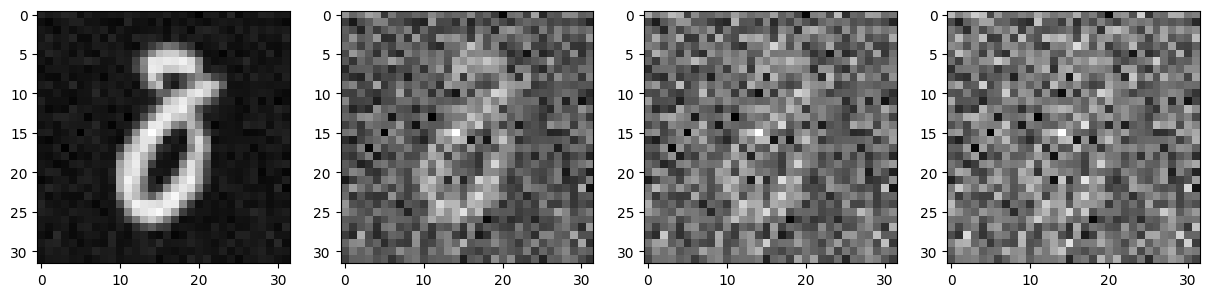

In [5]:
# this function will help us set the RNG key for Numpy
def set_key(key):
    np.random.seed(key)

# this function will add noise to the input as per the given timestamp
def forward_noise(key, x_0, t):
    set_key(key)
    noise = np.random.normal(size=x_0.shape)
    reshaped_sqrt_alpha_bar_t = np.reshape(np.take(sqrt_alpha_bar, t), (-1, 1, 1, 1))
    reshaped_one_minus_sqrt_alpha_bar_t = np.reshape(np.take(one_minus_sqrt_alpha_bar, t), (-1, 1, 1, 1))
    noisy_image = reshaped_sqrt_alpha_bar_t  * x_0 + reshaped_one_minus_sqrt_alpha_bar_t  * noise
    return keras.ops.convert_to_tensor(noisy_image, dtype=tf.float32), keras.ops.convert_to_tensor(noise, dtype=tf.float32)

# this function will be used to create sample timestamps between 0 & T
def generate_timestamp(key, num):
    set_key(key)
    return tf.random.uniform(shape=[num], minval=0, maxval=timesteps, dtype=tf.int32)

# Let us visualize the output image at a few timestamps
sample_mnist = next(iter(dataset))[0]

fig = plt.figure(figsize=(15, 30))

for index, i in enumerate([10, 100, 150, 199]):
    noisy_im, noise = forward_noise(0, np.expand_dims(sample_mnist, 0), np.array([i,]))
    plt.subplot(1, 4, index+1)
    plt.imshow(np.squeeze(np.squeeze(noisy_im, -1), 0), cmap='gray')

plt.savefig('noising_digits.png')
plt.show()

In [16]:
# -----------------------------------
# GELU activation
# -----------------------------------

def gelu(x, approximate=False):
    if approximate:
        coeff = tf.cast(0.044715, x.dtype)
        return 0.5 * x * (1.0 + tf.tanh(0.7978845608028654 * (x + coeff * tf.pow(x, 3))))
    else:
        return 0.5 * x * (1.0 + tf.math.erf(x / tf.cast(1.4142135623730951, x.dtype)))

class GELU(tf.keras.layers.Layer):
    def __init__(self, approximate=False):
        super(GELU, self).__init__()
        self.approximate = approximate

    def call(self, x, training=True):
        return gelu(x, self.approximate)
        
# -----------------------------------
# Time Embeddings
# -----------------------------------

# We will use this to convert timestamps to time encodings
class SinusoidalPosEmb(tf.keras.layers.Layer):
    def __init__(self, dim, max_positions=10000):
        super(SinusoidalPosEmb, self).__init__()
        self.dim = dim
        self.max_positions = max_positions

    def call(self, x, training=True):
        x = tf.cast(x, tf.float32)
        half_dim = self.dim // 2
        emb = math.log(self.max_positions) / (half_dim - 1)
        emb = tf.exp(tf.range(half_dim, dtype=tf.float32) * -emb)
        emb = x[:, None] * emb[None, :]

        emb = tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)

        return emb
        
def time_mlp(dim):
    time_dim = 4*dim

    return Sequential([
            SinusoidalPosEmb(dim),
            tf.keras.layers.Dense(units=time_dim, activation="gelu"),
#            GELU(),
            tf.keras.layers.Dense(units=time_dim)
        ], name="time embeddings")

# -----------------------------------
# Convolution block
# -----------------------------------
def conv_block(x, filters, time_emb):

    h = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    # Project timestep embedding
    t = tf.keras.layers.Dense(filters)(time_emb)

    # reshape for broadcasting
    t = tf.keras.layers.Reshape((1, 1, filters))(t)

    # add conditioning
    h = h + t

    h = tf.keras.activations.swish(h)

    h = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same"
    )(h)

    h = tf.keras.activations.swish(h)

    return h

# -----------------------------------
# Encoder block
# -----------------------------------
def encoder_block(x, filters, time_emb, name):
    f = conv_block(x, filters, time_emb)
    p = layers.MaxPooling2D((2, 2),name=name)(f)
    return f, p

# -----------------------------------
# Decoder block
# -----------------------------------
def decoder_block(x, skip, filters, time_emb, name):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same", name=name)(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, time_emb)
    return x

# -----------------------------------
# U-Net model
# -----------------------------------
def build_unet(input_shape=(32, 32, 1), num_classes=1):

    inputs = layers.Input(shape=input_shape, name="image")
    time_input = layers.Input((1,), dtype=tf.int32, name="timestep")

    time_emb = time_mlp(64)(time_input)
    
    # Encoder
    s1, p1 = encoder_block(inputs, 64, time_emb, "encoder_1")
    s2, p2 = encoder_block(p1, 128, time_emb, "encoder_2")
    s3, p3 = encoder_block(p2, 256, time_emb, "encoder_3")
    s4, p4 = encoder_block(p3, 512, time_emb, "encoder_4")

    # Bottleneck
    b1 = conv_block(p4, 1024, time_emb)

    # Decoder
    d1 = decoder_block(b1, s4, 512, time_emb, "decoder_1")
    d2 = decoder_block(d1, s3, 256, time_emb, "decoder_2")
    d3 = decoder_block(d2, s2, 128, time_emb, "decoder_3")
    d4 = decoder_block(d3, s1, 64, time_emb, "decoder_4")

    # Output layer
    if num_classes == 1:
        activation = "tanh"
    else:
        activation = "softmax"

    outputs = layers.Conv2D(
        num_classes,
        kernel_size=1,
        padding="same",
        activation=activation
    )(d4)

    model = Model([inputs, time_input], outputs, name="U-Net")

    return model

In [17]:
# create our unet model
unet = build_unet()
unet.summary()

# create our checkopint manager
#ckpt = tf.train.Checkpoint(unet=unet)
#ckpt_manager = tf.train.CheckpointManager(ckpt, "./checkpoints", max_to_keep=2)

# load from a previous checkpoint if it exists, else initialize the model from scratch
#if ckpt_manager.latest_checkpoint:
#    ckpt.restore(ckpt_manager.latest_checkpoint)
#    start_interation = int(ckpt_manager.latest_checkpoint.split("-")[-1])
#    print("Restored from {}".format(ckpt_manager.latest_checkpoint))
#else:
print("Initializing from scratch.")

# initialize the model in the memory of our GPU
test_images = tf.ones([1, 32, 32, 1])
test_timestamps = generate_timestamp(0, 1)
k = unet([test_images, test_timestamps])

# create our optimizer, we will use adam with a Learning rate of 1e-4
opt = keras.optimizers.Adam(learning_rate=1e-4)

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ timestep            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time embeddings     │ (None, 1, 256)    │     82,432 │ timestep[0][0]    │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 32, 32, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1, 64)     │     16,448 │ time              │
│                     │                   │            │ embeddings[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │        640 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_9 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 32, 32,    │          0 │ conv2d_20[0][0],  │
│                     │ 64)               │            │ reshape_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ silu_18 (Silu)      │ (None, 32, 32,    │          0 │ add_9[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │     36,928 │ silu_18[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ silu_19 (Silu)      │ (None, 32, 32,    │          0 │ conv2d_21[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_1           │ (None, 16, 16,    │          0 │ silu_19[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1, 128)    │     32,896 │ time              │
│                     │                   │            │ embeddings[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │     73,856 │ encoder_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 1, 1, 128) │          0 │ dense_17[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 16, 16,    │          0 │ conv2d_22[0][0],  │
│                     │ 128)              │            │ reshape_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ silu_20 (Silu)      │ (None, 16, 16,    │          0 │ add_10[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 16, 16,    │    147,584 │ silu_20[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 31,869,633 (121.57 MB)

 Trainable params: 31,869,633 (121.57 MB)

 Non-trainable params: 0 (0.00 B)

Initializing from scratch.


In [18]:
def loss_fn(real, generated):
    loss = tf.math.reduce_mean((real - generated) ** 2)
    return loss

In [19]:
rng = 0

def train_step(batch):
    rng, tsrng = np.random.randint(0, 100000, size=(2,))
#    print(f"rng: {rng}")
#    print(f"tsrng: {tsrng}")
    
    timestep_values = generate_timestamp(tsrng, batch.shape[0])

#    print(f"values: {timestep_values}")

    noised_image, noise = forward_noise(rng, batch, timestep_values)
    with tf.GradientTape() as tape:
        prediction = unet([noised_image, timestep_values])
        
        loss_value = loss_fn(noise, prediction)
    
    gradients = tape.gradient(loss_value, unet.trainable_variables)
    opt.apply_gradients(zip(gradients, unet.trainable_variables))

    return loss_value


epochs = 10
for e in range(1, epochs+1):
    # this is cool utility in Tensorflow that will create a nice looking progress bar
    bar = tf.keras.utils.Progbar(len(dataset)-1)
    losses = []
    for i, batch in enumerate(dataset):
        # run the training loop
        loss = train_step(batch)
        losses.append(loss)
        bar.update(i, values=[("loss", loss)])

    avg = np.mean(losses)
    print(f"Average loss for epoch {e}/{epochs}: {avg}")
#    ckpt_manager.save(checkpoint_number=e)

unet.save(f"unet_large_{epochs}.keras")

rng: 68268
tsrng: 43567
values: [ 40  31 161  62   4 197 112  16   4  52 178 151 116  29 144   7 102 168
  48  31  22 161  63  43 125  70 159  41  54 107  53  14  51  91 184 123
 140 149  95 153  92 114  18  43 139  33 118  16 143  36 111 174  37  80
  25 170 100  66  48   6   6  72  60  22]
   0/1093 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 1.0514rng: 90002
tsrng: 57541
values: [139 103 184  99 162 135  28 177 104 121 185 136  42  44  25  53  44  78
 114 135  53  14 173  65  73 179  98 115 178  64 186 125   9 132  51 159
  79  15 134 135  92  72 121  44 145  86  56  19 149 171   1  12   6  83
  96 131 186 169  47  60 199 192  51 167]
   1/1093 ━━━━━━━━━━━━━━━━━━━━ 2:52:09 9s/step - loss: 1.0453rng: 65312
tsrng: 56616
values: [ 16 184  68  11 189  20  36  86 133  10 105  30  32  16 122  76 111 117
 161   4  20 150 139  11 134 174  62  89  85  96  49 154 140 113 148 141
  45 135 130 196 108  71 171  56 156 113   9 106 186  46 150 130 173 111
 131  60  49  36 128  18 142 159   4  99]
   2

KeyboardInterrupt: 

In [8]:
# Save a GIF using logged images
def save_gif(img_list, path="", interval=200):
    # Transform images from [-1,1] to [0, 255]
    imgs = []
    for im in img_list:
        im = np.array(im)
        im = (im + 1) * 127.5
        im = np.clip(im, 0, 255).astype(np.int32)
        im = Image.fromarray(im)
        imgs.append(im)
    
    imgs = iter(imgs)

    # Extract first image from iterator
    img = next(imgs)

    # Append the other images and save as GIF
    img.save(fp=path, format='GIF', append_images=imgs,
             save_all=True, duration=interval, loop=0)

In [9]:
def ddpm(x_t, pred_noise, t):
    alpha_t = np.take(alpha, t)
    alpha_t_bar = np.take(alpha_bar, t)

    eps_coef = (1 - alpha_t) / (1 - alpha_t_bar) ** .5
    mean = (1 / (alpha_t ** .5)) * (x_t - eps_coef * pred_noise)

    var = np.take(beta, t)
    z = np.random.normal(size=x_t.shape)

    return mean + (var ** .5) * z

  0%|                                                   | 0/199 [00:00<?, ?it/s]

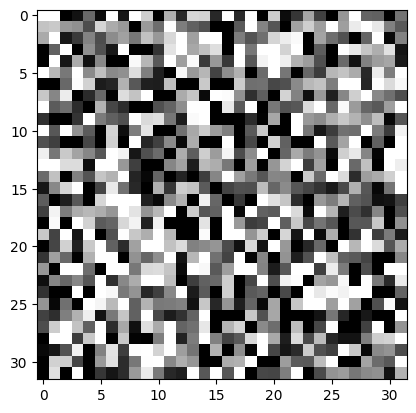

 13%|█████▎                                    | 25/199 [00:00<00:05, 32.99it/s]

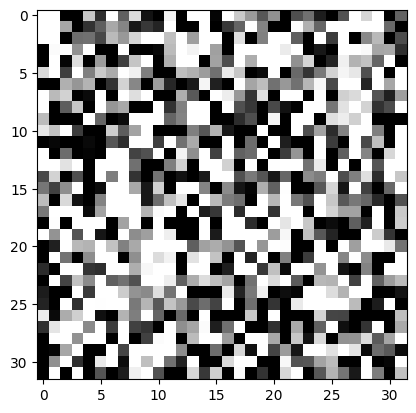

 25%|██████████▎                               | 49/199 [00:01<00:04, 32.51it/s]

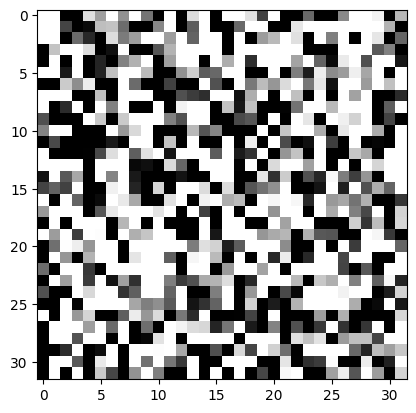

 37%|███████████████▍                          | 73/199 [00:02<00:03, 32.54it/s]

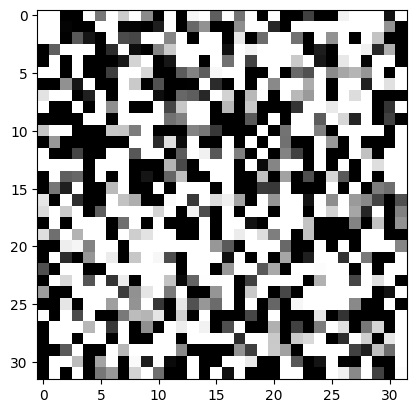

 49%|████████████████████▍                     | 97/199 [00:03<00:03, 32.77it/s]

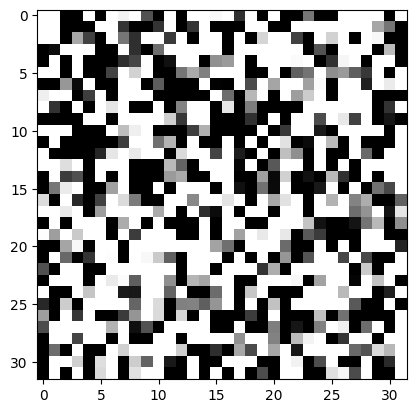

 63%|█████████████████████████▊               | 125/199 [00:04<00:02, 33.14it/s]

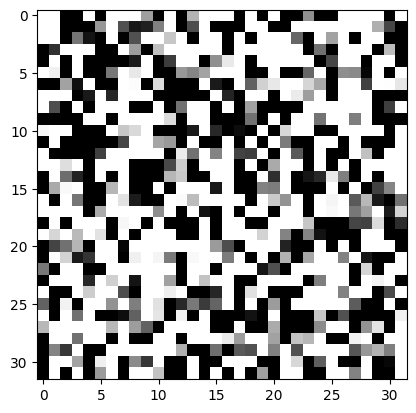

 75%|██████████████████████████████▋          | 149/199 [00:04<00:01, 32.89it/s]

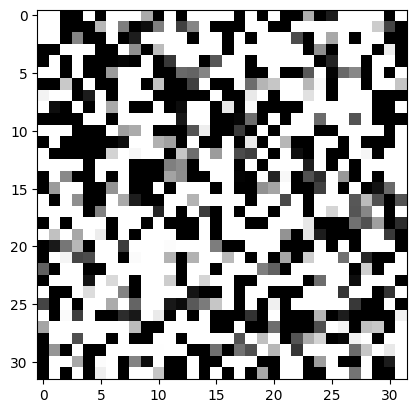

 87%|███████████████████████████████████▋     | 173/199 [00:05<00:00, 32.61it/s]

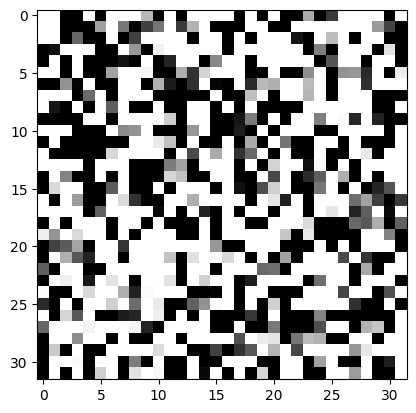

100%|█████████████████████████████████████████| 199/199 [00:06<00:00, 30.18it/s]


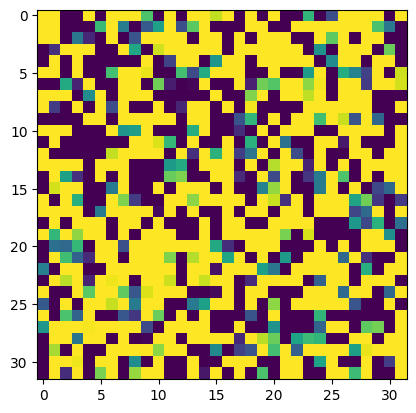

In [11]:
x = tf.random.normal((1,32,32,1))
img_list = []
img_list.append(np.squeeze(np.squeeze(x, 0),-1))

for i in tqdm(range(timesteps-1)):
    t = keras.ops.convert_to_tensor(np.expand_dims(np.array(timesteps-i-1, np.int32), 0))
    pred_noise = unet([x, t])
    x = ddpm(x, pred_noise, t)
    img_list.append(np.squeeze(np.squeeze(x, 0),-1))

    if i % 25==0:
        plt.imshow(np.array(np.clip((x[0] + 1) * 127.5, 0, 255), np.uint8), cmap="gray")
        plt.show()

save_gif(img_list + ([img_list[-1]] * 100), f"ddpm_large_{epochs}.gif", interval=20)

plt.imshow(np.array(np.clip((x[0] + 1) * 127.5, 0, 255), np.uint8))
plt.show()